# Treatment Escalation Following Metformin Initiation in Type 2 Diabetes
## A Descriptive Observational Study Using OMOP CDM Data

**Research Question:** Among adults with T2DM initiating metformin monotherapy, what demographic and clinical characteristics are associated with the *timing* of second-line antidiabetic therapy initiation?

**Study Design:** Descriptive observational study of new metformin users who subsequently initiated second-line antidiabetic therapy. Time to escalation is measured from the metformin index date to the first non-metformin antidiabetic prescription.

**Analytic Layers:**
1. **Descriptive Analysis** — Cohort characteristics, escalation rates, top agents
2. **Survival Analysis** — Kaplan-Meier curves and Cox proportional hazards regression
3. **Stratified Analyses** — By gender, race, ethnicity, age group, CHD, CKD, depression, hypertension
4. **Treatment Pathway Analysis** — Common sequences of therapy following metformin

**Team:** Giselle Feng (fg2618) and Nikhil Anand (na3213)

## 0. Setup and Imports

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

## 1. Data Loading and Cleaning

The raw data is at the **drug-exposure level**: each row represents one second-line drug exposure for a patient. A single patient may have multiple rows if they received multiple second-line agents over time.

The cleaning function below:
- Parses dates and standardizes categorical variables
- Standardizes drug names to lowercase for consistency
- Computes derived time variables (time to first escalation, follow-up duration)
- Collapses the data to **one row per patient** using the *first* second-line initiation event
- Creates age group bins for stratified analysis
- Computes censor date as min(cohort_start_date + 270 days, observation_period_end_date)

In [72]:
def clean_and_prepare(filepath):
    """
    Load raw drug-exposure-level data and return two DataFrames:
      1. df_raw  — all exposures within the study window (for pathway analysis)
      2. df      — one row per patient, first escalation event (for survival analysis)
    """

    raw = pd.read_csv(filepath)
    print(f"Raw data: {len(raw)} rows, {raw['person_id'].nunique()} unique patients")

    # --- Parse dates ---
    date_cols = [
        "cohort_start_date",
        "cohort_end_date",
        "observation_period_start_date",
        "observation_period_end_date",
        "second_line_start_date",
        "second_line_end_date",
        "censor_date",
    ]
    for col in date_cols:
        raw[col] = pd.to_datetime(raw[col], errors="coerce")

    # --- Drop exposures outside the study window ---
    before = len(raw)
    raw = raw[raw["second_line_start_date"] <= raw["cohort_end_date"]].copy()
    dropped = before - len(raw)
    print(f"Dropped {dropped} exposures after study end date (cohort_end_date)")
    print(f"Remaining: {len(raw)} exposures, {raw['person_id'].nunique()} patients")

    # --- Standardize ---
    raw["second_line_drug_name"] = raw["second_line_drug_name"].str.strip().str.lower()
    raw["gender"] = raw["gender"].str.strip().str.upper()
    raw["race"] = raw["race"].str.strip()
    raw["ethnicity"] = raw["ethnicity"].str.strip()

    # --- Days from metformin start to each exposure ---
    raw["days_to_drug"] = (
        raw["second_line_start_date"] - raw["cohort_start_date"]
    ).dt.days

    # --- Flag anomalies ---
    neg = raw[raw["days_to_drug"] < 0]
    if len(neg) > 0:
        print(f"WARNING: {len(neg)} exposures with negative time. Removing.")
        raw = raw[raw["days_to_drug"] >= 0].copy()

    same_day = raw[raw["days_to_drug"] == 0]
    if len(same_day) > 0:
        print(
            f"NOTE: {len(same_day)} exposures on day 0 (same day as metformin start)."
        )

    # --- Study period length ---
    raw["study_period_days"] = (
        raw["cohort_end_date"] - raw["cohort_start_date"]
    ).dt.days
    print(
        f"Study period: {raw['study_period_days'].iloc[0]} days "
        f"({raw['cohort_start_date'].iloc[0].date()} to {raw['cohort_end_date'].iloc[0].date()})"
    )

    # --- Save cleaned full dataset for pathway analysis ---
    df_raw = raw.copy()

    # --- Collapse to one row per patient: first second-line event ---
    raw = raw.sort_values(["person_id", "second_line_start_date"])
    df = raw.groupby("person_id").first().reset_index()

    # --- Time to first escalation ---
    df["time_to_escalation"] = (
        df["second_line_start_date"] - df["cohort_start_date"]
    ).dt.days

    print(
        "Number of records with zero time to escalation days",
        len(df[df["time_to_escalation"] == 0]),
    )
    print("These will be pruned!")
    df = df[df["time_to_escalation"] > 0]

    # --- Diabetes Duration ---
    df = df[df["diabetes_duration_days"] > 0]
    df["diabetes_duration"] = pd.cut(
        df["diabetes_duration_days"],
        bins=[0, 90, 180, 365, 650],
        labels=["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"],
    )
    df["diabetes_duration"] = pd.Categorical(
        df["diabetes_duration"],
        categories=["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"],
        ordered=True,
    )

    # --- Event indicator (all = 1, everyone escalated) ---
    df["event"] = 1

    # --- Age groups ---
    df["age_group"] = pd.cut(
        df["age_at_index"],
        bins=[17, 44, 64, 74, 120],
        labels=["18-44", "45-64", "65-74", "75+"],
    )

    # --- Rename flags ---
    df = df.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )
    df_raw = df_raw.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )

    print("Removing any records where the time to escalation equals the study period")
    df = df[df["study_period_days"] > df["time_to_escalation"]]

    print(f"\nPatient-level data: {len(df)} patients")
    print(f"  Median time to escalation: {df['time_to_escalation'].median():.0f} days")
    print(
        f"  Range: {df['time_to_escalation'].min()} – {df['time_to_escalation'].max()} days"
    )

    return df_raw, df


df_raw, df = clean_and_prepare("../Data/cohort_raw.csv")
df.head()

Raw data: 25182 rows, 9951 unique patients
Dropped 8419 exposures after study end date (cohort_end_date)
Remaining: 16763 exposures, 9116 patients
NOTE: 1867 exposures on day 0 (same day as metformin start).
Study period: 15 days (2009-12-13 to 2009-12-28)
Number of records with zero time to escalation days 1860
These will be pruned!
Removing any records where the time to escalation equals the study period

Patient-level data: 4679 patients
  Median time to escalation: 67 days
  Range: 1 – 326 days


,person_id,gender,race,ethnicity,age_at_index,cohort_start_date,first_t2dm_date,diabetes_duration_days,cohort_end_date,observation_period_start_date,...,depression,chd,ckd,censor_date,days_to_drug,study_period_days,time_to_escalation,diabetes_duration,event,age_group
3,82,MALE,White,Not Hispanic or Latino,81,2009-05-01,2008-01-05,482,2010-03-31,2008-01-05,...,0,1,0,NaT,38,334,38,1–2+ yr,1,75+
4,83,FEMALE,White,Not Hispanic or Latino,46,2009-05-30,2008-05-16,379,2010-02-16,2008-02-08,...,1,1,0,2010-02-16,132,262,132,1–2+ yr,1,45-64
7,142,FEMALE,White,Not Hispanic or Latino,72,2009-01-27,2008-01-30,363,2009-12-27,2008-01-24,...,0,0,0,2010-06-06,250,334,250,6–12 mo,1,65-74
8,147,FEMALE,White,Not Hispanic or Latino,83,2009-06-21,2008-06-05,381,2010-05-21,2008-01-18,...,0,1,1,NaT,135,334,135,1–2+ yr,1,75+
10,178,MALE,White,Not Hispanic or Latino,81,2009-03-18,2008-02-24,388,2010-02-15,2008-01-17,...,1,1,1,2010-04-14,34,334,34,1–2+ yr,1,75+


---
## Layer 1: Descriptive Analysis

### 1.1 Table 1 — Baseline Characteristics

Standard summary of cohort demographics and comorbidities, reported as counts and percentages for categorical variables, and median (IQR) for continuous variables.

In [73]:
def make_table1(df):
    """Generate a Table 1 of baseline characteristics."""

    rows = []
    N = len(df)

    # --- Continuous: Age ---
    med = df["age_at_index"].median()
    q1 = df["age_at_index"].quantile(0.25)
    q3 = df["age_at_index"].quantile(0.75)
    rows.append(("Median Age at Index (IQR)", f"{med:.0f} ({q1:.0f}–{q3:.0f})", ""))

    # --- Continuous: Time to escalation ---
    med_t = df["time_to_escalation"].median()
    q1_t = df["time_to_escalation"].quantile(0.25)
    q3_t = df["time_to_escalation"].quantile(0.75)
    rows.append(
        (
            "Time to escalation (days), median (IQR)",
            f"{med_t:.0f} ({q1_t:.0f}–{q3_t:.0f})",
            "",
        )
    )

    rows.append(("", "", ""))  # spacer

    # --- Categorical variables ---
    cat_vars = {
        "Gender": "gender",
        "Race": "race",
        "Ethnicity": "ethnicity",
        "Age group": "age_group",
        "Diabetes Duration": "diabetes_duration",
    }
    for label, col in cat_vars.items():
        rows.append((f"**{label}**", "n", "%"))
        for val in sorted(df[col].dropna().unique()):
            n = (df[col] == val).sum()
            pct = n / N * 100
            rows.append((f"  {val}", str(n), f"{pct:.1f}%"))

    # --- Binary comorbidity flags ---
    rows.append(("", "", ""))
    rows.append(("**Comorbidities**", "n", "%"))
    for label, col in [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ]:
        n = df[col].sum()
        pct = n / N * 100
        rows.append((f"  {label}", str(int(n)), f"{pct:.1f}%"))

    # --- Comorbidity count ---
    df_temp = df.copy()
    df_temp["comorbidity_count"] = df_temp[
        ["hypertension", "depression", "chd", "ckd"]
    ].sum(axis=1)
    med_c = df_temp["comorbidity_count"].median()
    mean_c = df_temp["comorbidity_count"].mean()
    rows.append(
        (f"Comorbidity count (of 4), median (mean)", f"{med_c:.0f} ({mean_c:.1f})", "")
    )

    table1 = pd.DataFrame(rows, columns=["Characteristic", "Value", ""])
    return table1


table1 = make_table1(df)
print("TABLE 1: Baseline Characteristics")
print("=" * 60)
print(table1.to_string(index=False))

TABLE 1: Baseline Characteristics
                         Characteristic       Value       
              Median Age at Index (IQR)  74 (67–82)       
Time to escalation (days), median (IQR) 67 (30–127)       
                                                          
                             **Gender**           n      %
                                 FEMALE        2906  62.1%
                                   MALE        1773  37.9%
                               **Race**           n      %
              Black or African American         591  12.6%
                                  White        4088  87.4%
                          **Ethnicity**           n      %
                 Not Hispanic or Latino        4679 100.0%
                          **Age group**           n      %
                                  18-44         202   4.3%
                                  45-64         738  15.8%
                                  65-74        1545  33.0%
                      

In [74]:
df["diabetes_duration_days"].describe()

count    4679.000000
mean      350.229964
std       130.997943
min         1.000000
25%       272.000000
50%       362.000000
75%       439.000000
max       674.000000
Name: diabetes_duration_days, dtype: float64

### 1.2 Top Second-Line Agents

Distribution of the first second-line antidiabetic agent initiated after metformin.

First second-line agent initiated after metformin:
---------------------------------------------
  glyburide             n=1825  (39.0%)
  glipizide             n=1444  (30.9%)
  glimepiride           n=454  (9.7%)
  rosiglitazone         n=404  (8.6%)
  pioglitazone          n=324  (6.9%)
  repaglinide           n= 80  (1.7%)
  sitagliptin           n= 78  (1.7%)
  nateglinide           n= 49  (1.0%)
  insulin glargine      n= 15  (0.3%)
  insulin detemir       n=  4  (0.1%)
  saxagliptin           n=  2  (0.0%)
                      N=4679


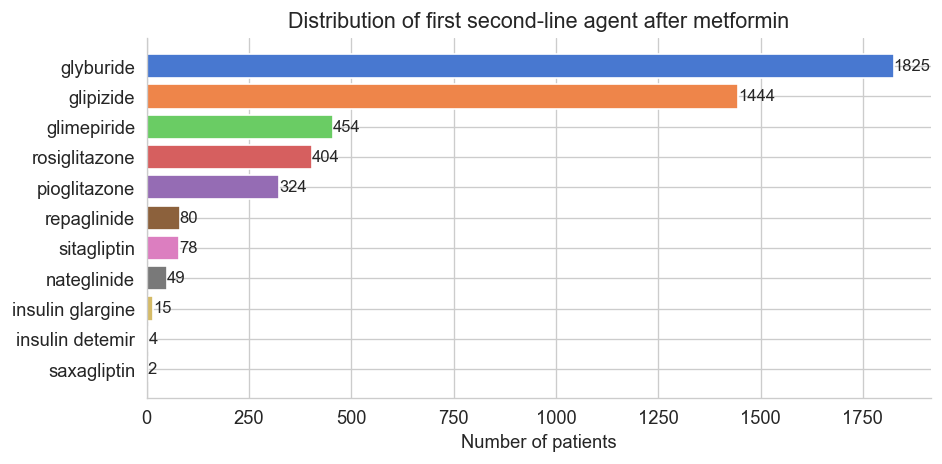

<Figure size 1200x720 with 0 Axes>

In [75]:
# Top second-line agents (first agent per patient)
drug_counts = df["second_line_drug_name"].value_counts()
drug_pcts = (drug_counts / len(df) * 100).round(1)

print("First second-line agent initiated after metformin:")
print("-" * 45)
for drug, n in drug_counts.items():
    print(f"  {drug:<20s}  n={n:>3d}  ({drug_pcts[drug]:.1f}%)")
print(f"{'':20s}  N={drug_counts.sum():>3d}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("muted", len(drug_counts))
bars = ax.barh(
    drug_counts.index[::-1],
    drug_counts.values[::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Number of patients")
ax.set_title("Distribution of first second-line agent after metformin")
for bar, val in zip(bars, drug_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
plt.savefig("./figures/first-line-agent-distribution.png")

### 1.3 Distribution of Time to Escalation

Histogram and descriptive statistics for the primary outcome: days from metformin initiation to first second-line drug.

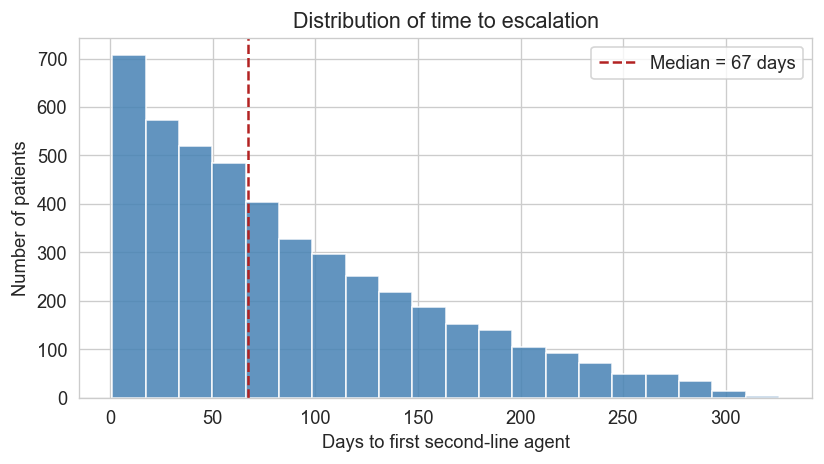

<Figure size 1200x720 with 0 Axes>

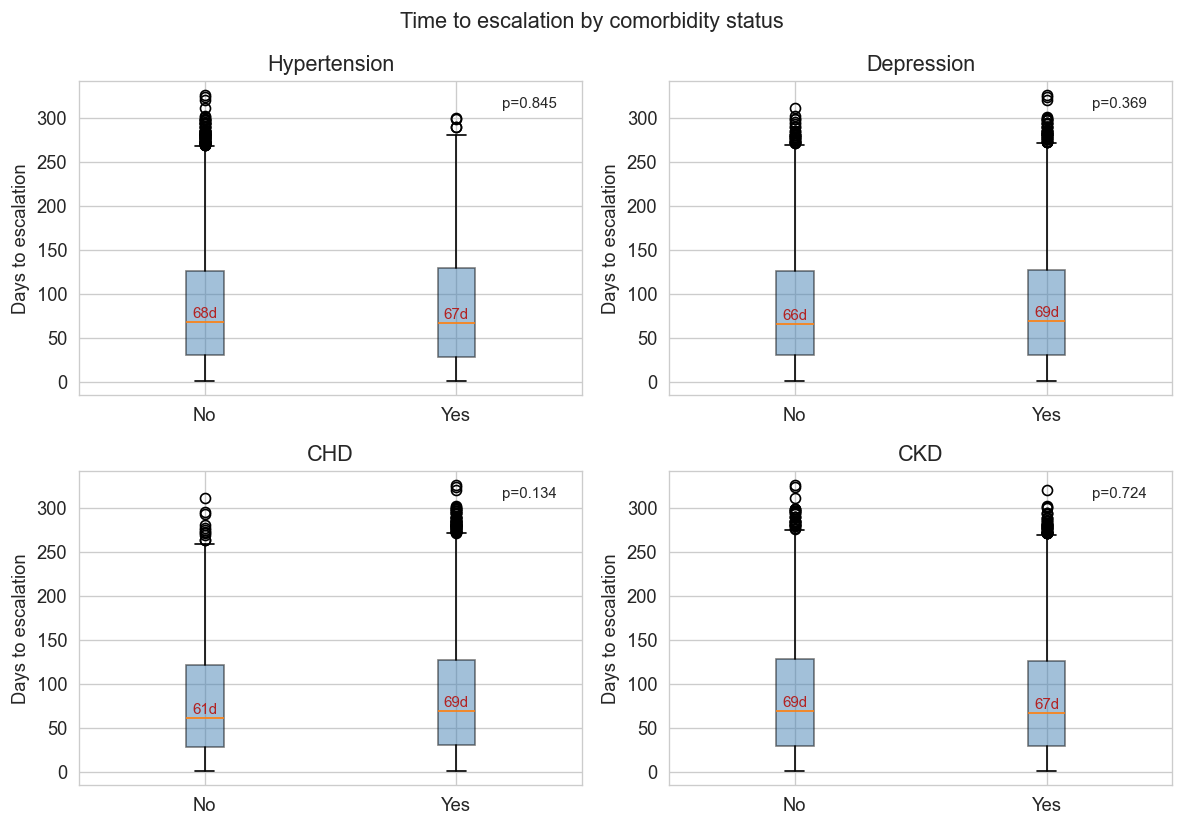

<Figure size 1200x720 with 0 Axes>

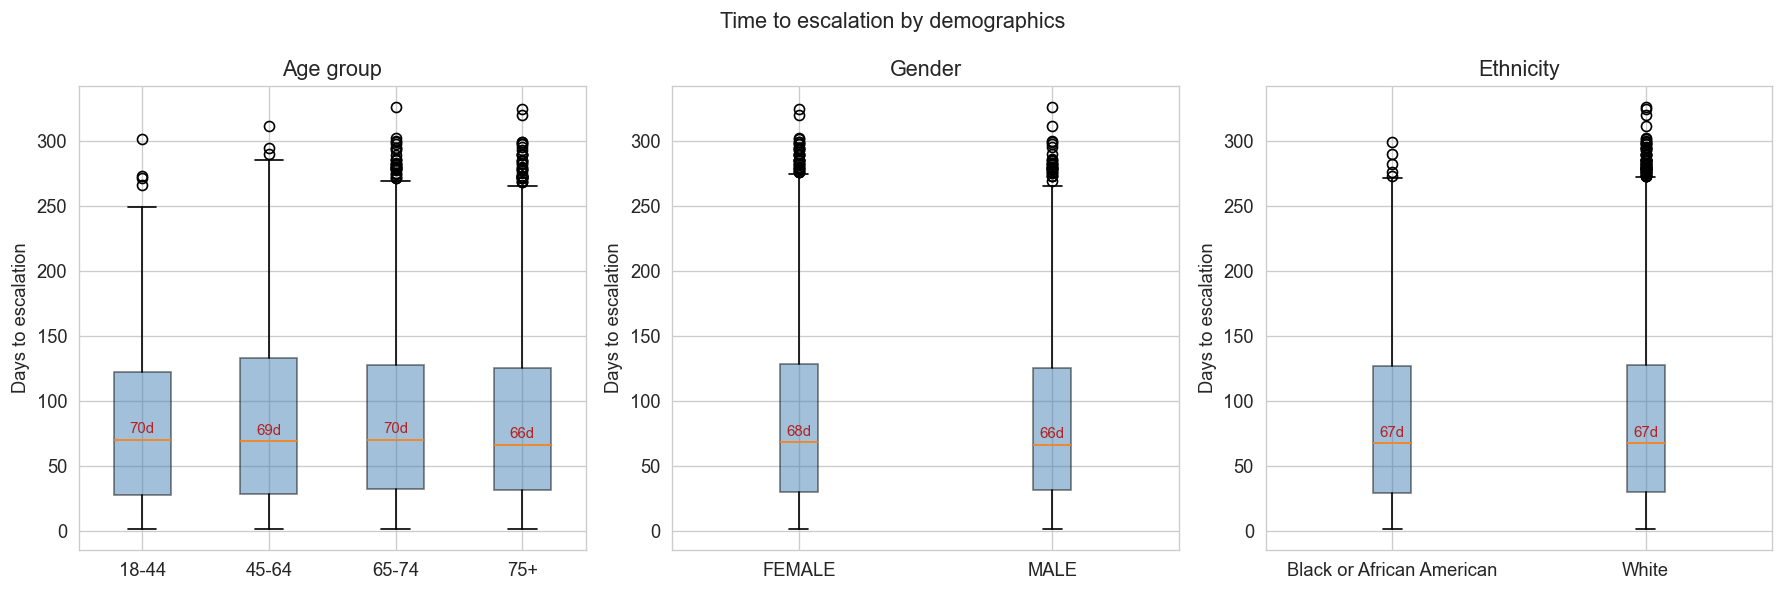


Descriptive statistics — Time to escalation (days):
count    4679.0
mean       85.9
std        69.0
min         1.0
25%        30.0
50%        67.0
75%       127.0
max       326.0
Name: time_to_escalation, dtype: float64


<Figure size 1200x720 with 0 Axes>

In [76]:
# --- Figure 1: Distribution of time to escalation ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    df["time_to_escalation"], bins=20, color="steelblue", edgecolor="white", alpha=0.85
)
ax.axvline(
    df["time_to_escalation"].median(),
    color="firebrick",
    linestyle="--",
    label=f"Median = {df['time_to_escalation'].median():.0f} days",
)
ax.set_xlabel("Days to first second-line agent")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of time to escalation")
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("./figures/time-to-escalation.png")

# --- Figure 2: Time to escalation by comorbidity ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (label, col) in zip(
    axes.ravel(),
    [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ],
):
    data_0 = df[df[col] == 0]["time_to_escalation"]
    data_1 = df[df[col] == 1]["time_to_escalation"]
    ax.boxplot(
        [data_0, data_1],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    medians = df.groupby(col)["time_to_escalation"].median()
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick")
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
        ax.text(0.95, 0.95, f"p={p:.3f}", transform=ax.transAxes, ha="right", va="top", fontsize=9)
plt.suptitle("Time to escalation by comorbidity status", fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig("./figures/time-to-escalation-comorbidity.png")

# --- Figure 3: Time to escalation by age group, gender, ethnicity ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, col) in zip(
    axes,
    [("Age group", "age_group"), ("Gender", "gender"), ("Ethnicity", "race")],
):
    grouped = df.groupby(col)["time_to_escalation"]
    keys = list(grouped.groups.keys())
    labels = [str(k) for k in keys]
    groups = [grouped.get_group(k).dropna().values for k in keys]
    ax.boxplot(
        groups,
        labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    ax.tick_params(axis="x", rotation=0)
    medians = grouped.median()
    for i, med in enumerate(medians.values):
        ax.text(i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick")
plt.suptitle("Time to escalation by demographics", fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig("./figures/time-to-escalation-demographics.png")

# Summary stats
print("\nDescriptive statistics — Time to escalation (days):")
print(df["time_to_escalation"].describe().round(1))

### 1.4 Comorbidity Co-occurrence

Cross-tabulation of baseline comorbidities to understand burden and co-occurrence patterns.

Comorbidity count distribution:
comorbidity_count
0     315
1     972
2    1629
3    1547
4     216
Name: count, dtype: int64

Comorbidity co-occurrence matrix (counts):
              hypertension  depression   chd   ckd
hypertension           467         309   435   313
depression             309        2527  2347  1671
chd                    435        2347  4058  2491
ckd                    313        1671  2491  2683


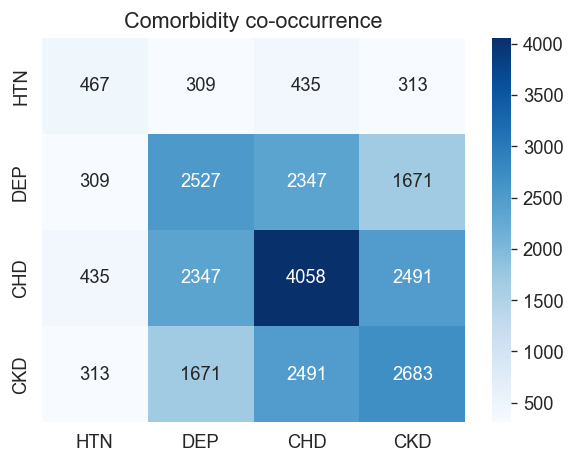

<Figure size 1200x720 with 0 Axes>

In [77]:
comorbidity_cols = ["hypertension", "depression", "chd", "ckd"]

# Comorbidity count distribution
df["comorbidity_count"] = df[comorbidity_cols].sum(axis=1)
print("Comorbidity count distribution:")
print(df["comorbidity_count"].value_counts().sort_index())
print()

# Co-occurrence matrix
co_matrix = pd.DataFrame(index=comorbidity_cols, columns=comorbidity_cols, dtype=float)
for c1 in comorbidity_cols:
    for c2 in comorbidity_cols:
        if c1 == c2:
            co_matrix.loc[c1, c2] = df[c1].sum()
        else:
            co_matrix.loc[c1, c2] = ((df[c1] == 1) & (df[c2] == 1)).sum()

print("Comorbidity co-occurrence matrix (counts):")
print(co_matrix.astype(int))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    co_matrix.astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["HTN", "DEP", "CHD", "CKD"],
    yticklabels=["HTN", "DEP", "CHD", "CKD"],
)
ax.set_title("Comorbidity co-occurrence")
plt.tight_layout()
plt.show()
plt.savefig("./figures/comorbidity-cooccurrence.png")

### 1.5 Time to Escalation by Comorbidity Status

Comparing median escalation times across comorbidity subgroups to identify preliminary patterns before formal modeling.

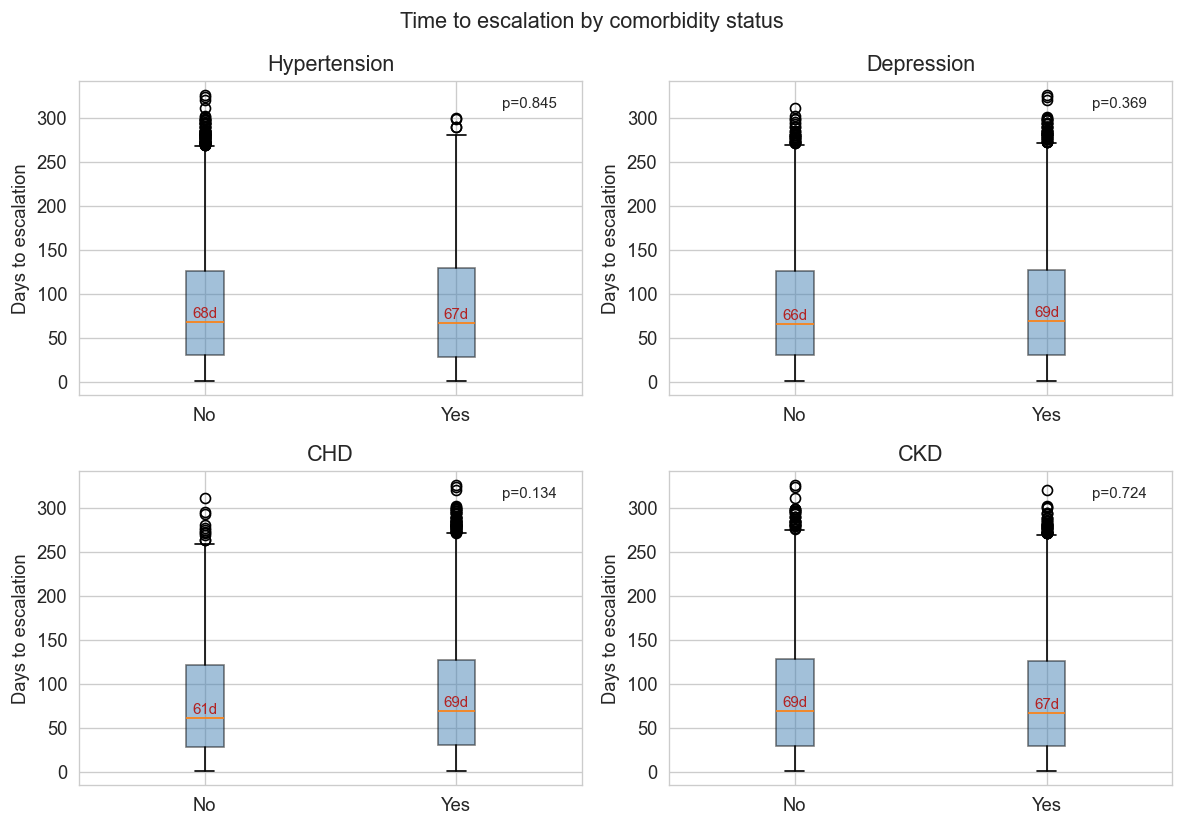

<Figure size 1200x720 with 0 Axes>

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, (label, col) in zip(
    axes.ravel(),
    [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ],
):
    groups = df.groupby(col)["time_to_escalation"]
    medians = groups.median()

    data_0 = df[df[col] == 0]["time_to_escalation"]
    data_1 = df[df[col] == 1]["time_to_escalation"]

    ax.boxplot(
        [data_0, data_1],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(f"{label}")
    ax.set_ylabel("Days to escalation")

    # Add median labels
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(
            i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick"
        )

    # Mann-Whitney U test
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
        ax.text(
            0.95,
            0.95,
            f"p={p:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )

plt.suptitle("Time to escalation by comorbidity status", fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig("./figures/time-to-escalation-by-comorbidity.png")

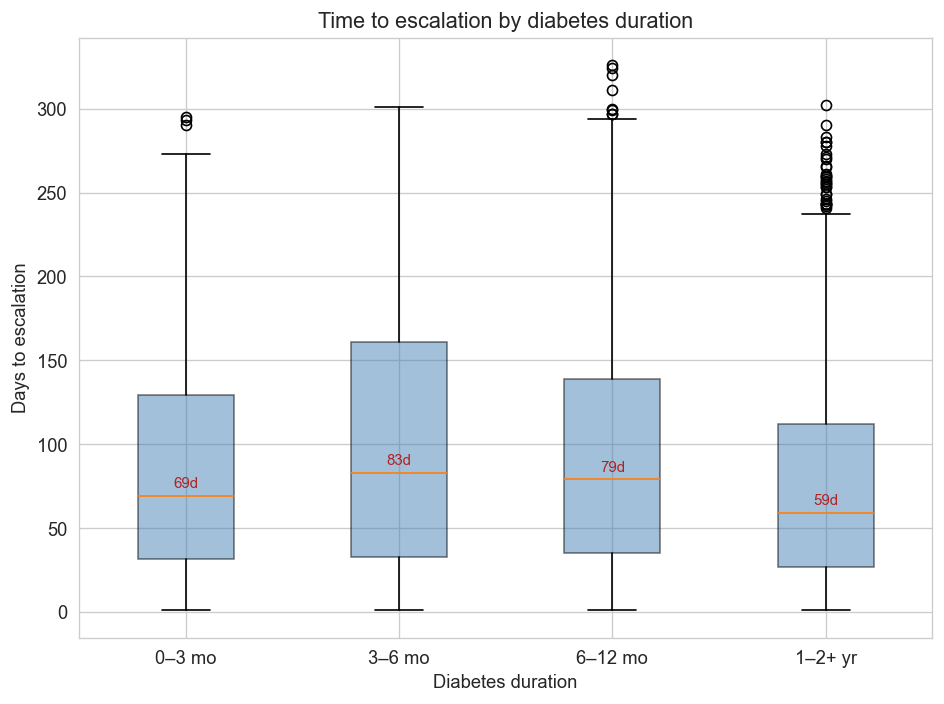

<Figure size 1200x720 with 0 Axes>

In [79]:
import matplotlib.pyplot as plt
from scipy import stats

order = ["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"]

# Make sure the categories stay in the order you want
df["diabetes_duration"] = pd.Categorical(
    df["diabetes_duration"], categories=order, ordered=True
)

fig, ax = plt.subplots(figsize=(8, 6))

grouped_data = [
    df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].dropna()
    for grp in order
]

medians = {
    grp: df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].median()
    for grp in order
}

ax.boxplot(
    grouped_data,
    labels=order,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)

ax.set_title("Time to escalation by diabetes duration")
ax.set_ylabel("Days to escalation")
ax.set_xlabel("Diabetes duration")

# Add median labels
for i, grp in enumerate(order, start=1):
    med = medians[grp]
    if pd.notna(med):
        ax.text(
            i,
            med + 5,
            f"{med:.0f}d",
            ha="center",
            fontsize=9,
            color="firebrick",
        )


plt.tight_layout()
plt.show()
plt.savefig("./figures/time-to-escalation-diabetes.png")

---
## Layer 2: Survival Analysis

### 2.1 Overall Kaplan-Meier Curve

Since all patients in this dataset were escalated (event = 1 for all), the KM curve shows the cumulative proportion who have been escalated over time. There are no censored observations.

**Limitation:** This dataset includes only patients who *were* escalated. Patients who remained on metformin monotherapy throughout the observation period are excluded. The KM curve therefore represents the distribution of escalation timing conditional on escalation occurring, not the overall probability of escalation in the full cohort.

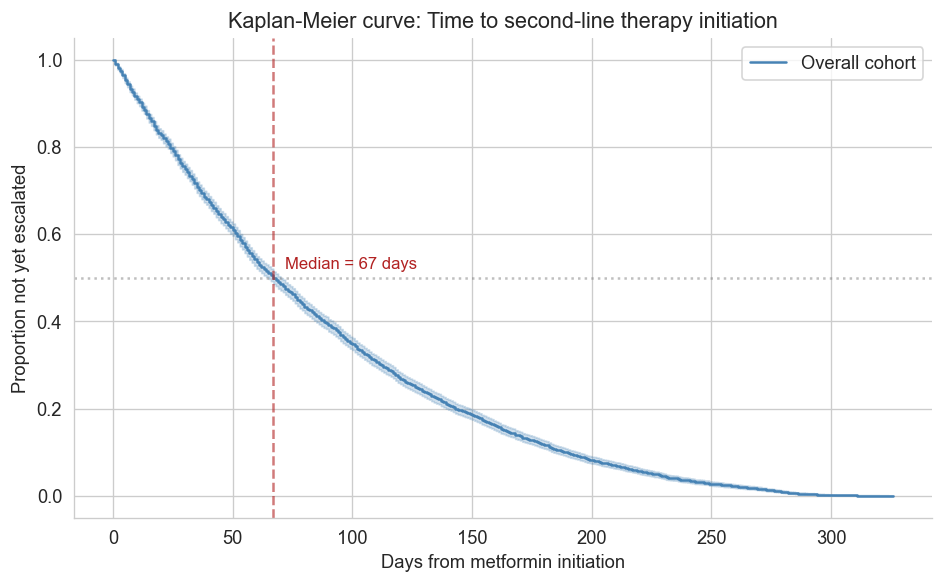

Median time to escalation: 67 days
Mean time to escalation: 85.9 days


<Figure size 1200x720 with 0 Axes>

In [80]:
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(8, 5))

kmf.fit(df["time_to_escalation"], event_observed=df["event"], label="Overall cohort")
kmf.plot_survival_function(ax=ax, ci_show=True, color="steelblue")

ax.set_xlabel("Days from metformin initiation")
ax.set_ylabel("Proportion not yet escalated")
ax.set_title("Kaplan-Meier curve: Time to second-line therapy initiation")
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)

median_surv = kmf.median_survival_time_
ax.axvline(x=median_surv, color="firebrick", linestyle="--", alpha=0.6)
ax.text(
    median_surv + 5,
    0.52,
    f"Median = {median_surv:.0f} days",
    color="firebrick",
    fontsize=10,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
plt.savefig("./figures/km.png")

print(f"Median time to escalation: {median_surv:.0f} days")
print(f"Mean time to escalation: {df['time_to_escalation'].mean():.1f} days")

### 2.2 Kaplan-Meier Curves — Stratified

KM curves stratified by each demographic and clinical characteristic, with log-rank tests for group differences.

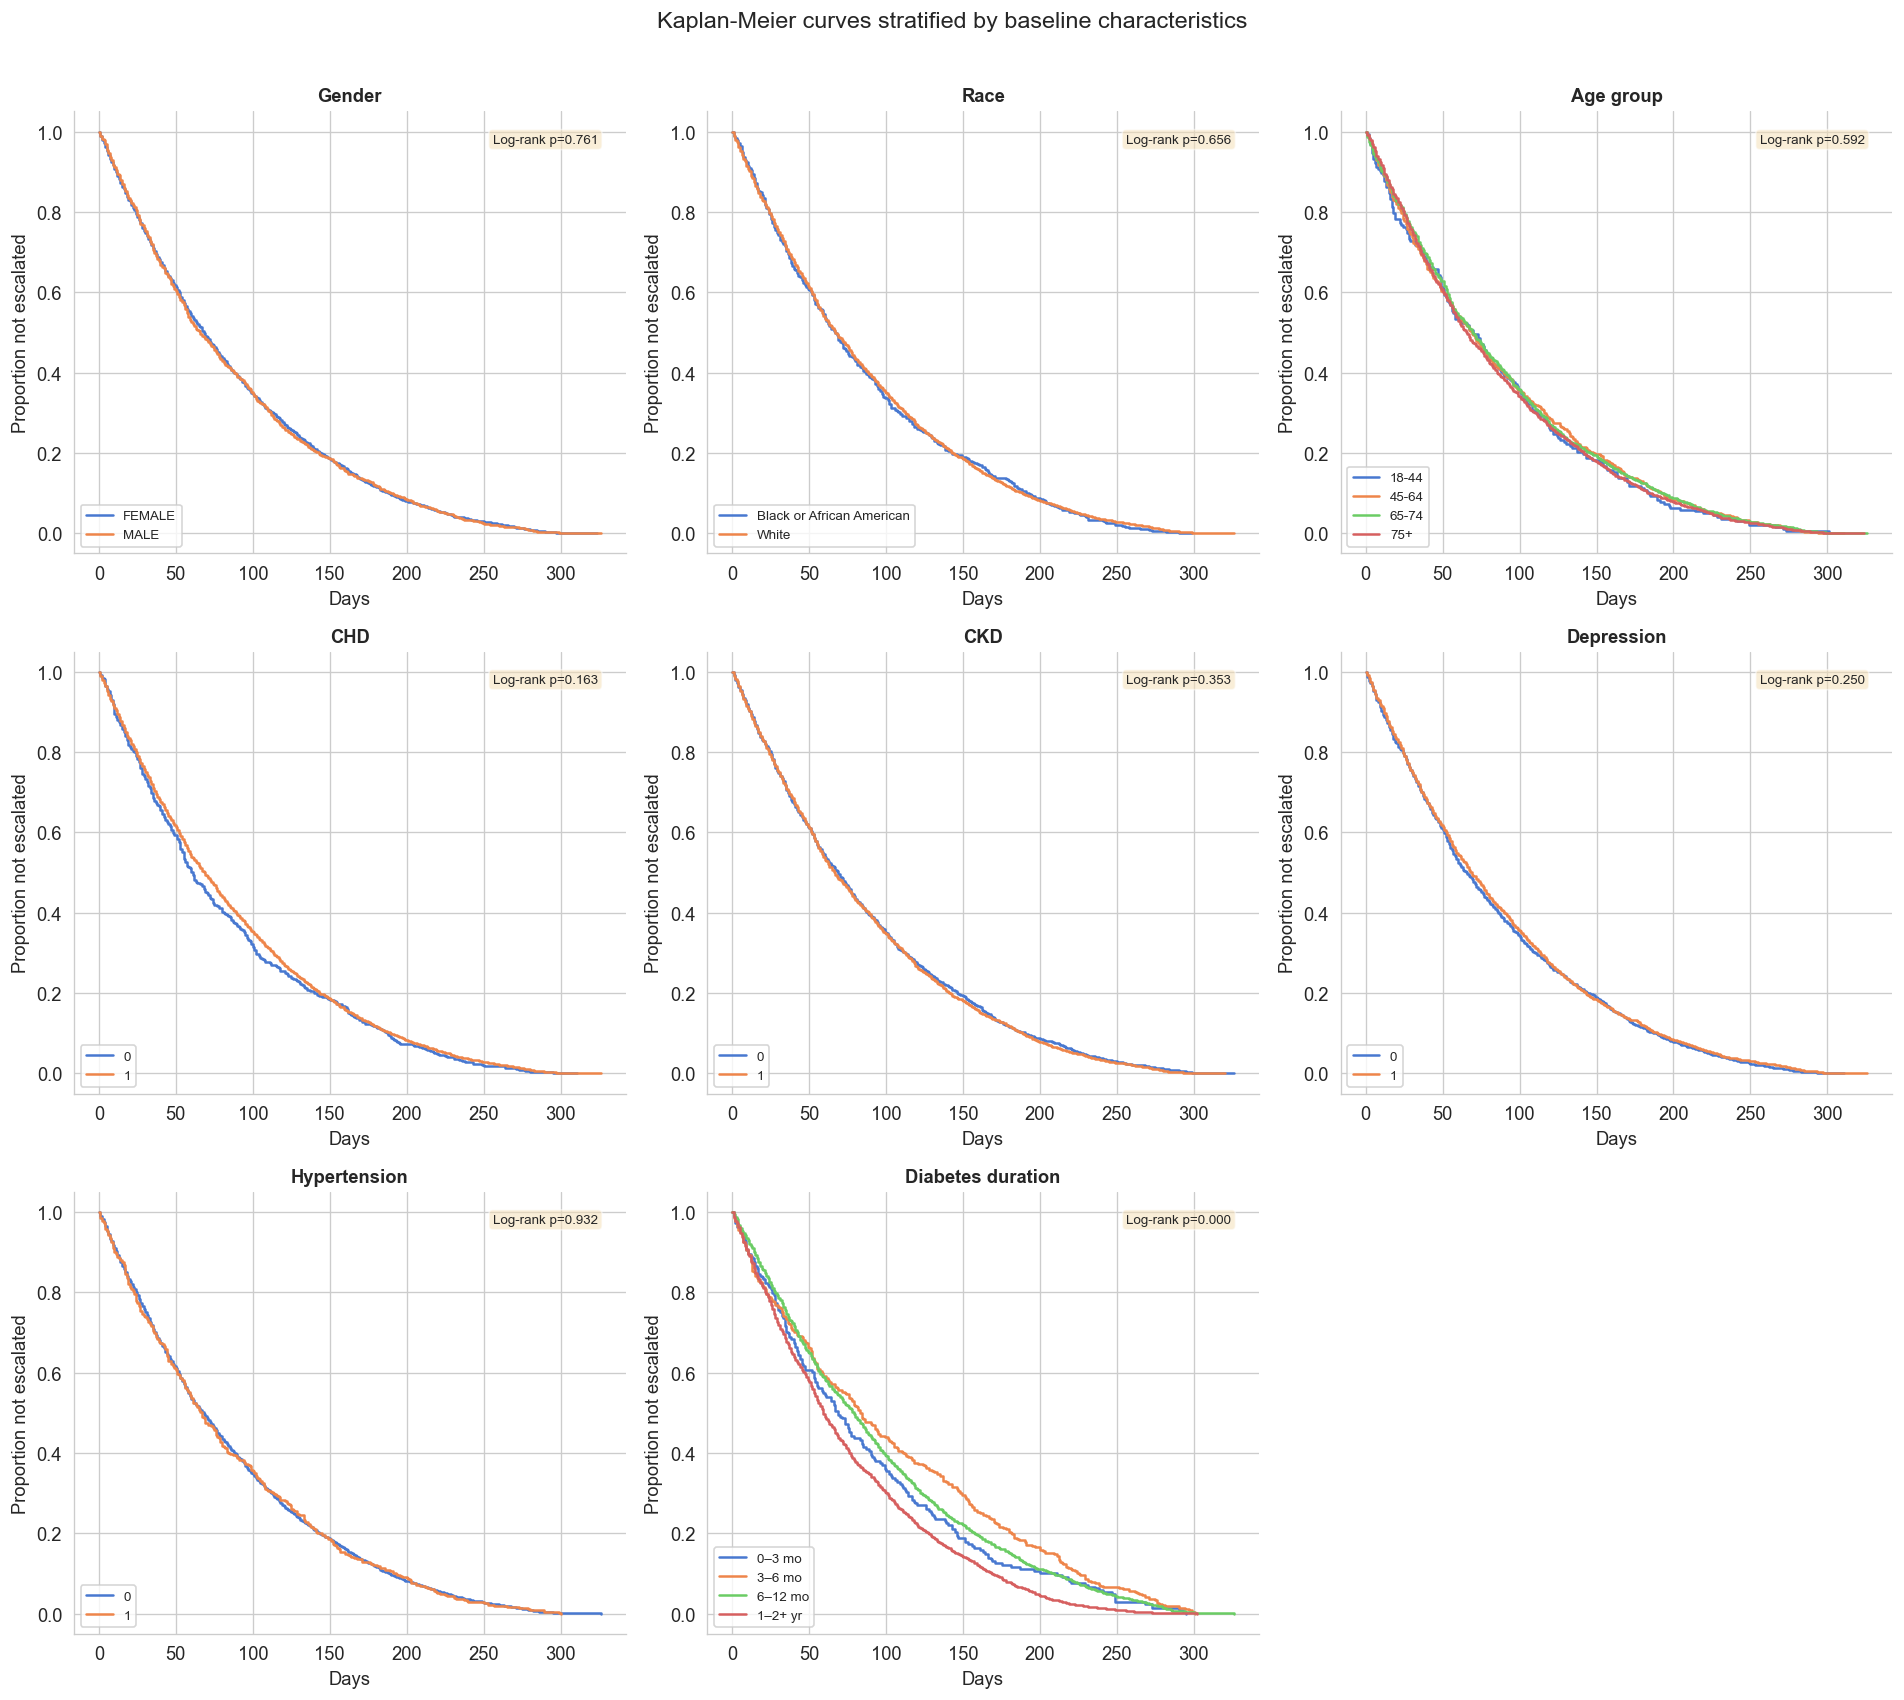

<Figure size 1200x720 with 0 Axes>

In [81]:
strat_vars = {
    "Gender": "gender",
    "Race": "race",
    "Age group": "age_group",
    "CHD": "chd",
    "CKD": "ckd",
    "Depression": "depression",
    "Hypertension": "hypertension",
    "Diabetes duration": "diabetes_duration",
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()

kmf = KaplanMeierFitter()

for idx, (title, col) in enumerate(strat_vars.items()):
    ax = axes[idx]

    if col == "diabetes_duration":
        order = ["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"]
        df[col] = pd.Categorical(df[col], categories=order, ordered=True)
        groups = [g for g in order if g in df[col].dropna().unique()]
    else:
        groups = df[col].dropna().unique()
        groups = sorted(groups, key=lambda x: str(x))

    palette = sns.color_palette("muted", len(groups))

    for i, grp in enumerate(groups):
        mask = df[col] == grp
        if mask.sum() < 2:
            continue
        kmf.fit(
            df.loc[mask, "time_to_escalation"],
            event_observed=df.loc[mask, "event"],
            label=str(grp),
        )
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Days")
    ax.set_ylabel("Proportion not escalated")
    ax.legend(fontsize=8, loc="lower left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    valid_groups = [g for g in groups if (df[col] == g).sum() >= 2]
    if len(valid_groups) >= 2:
        try:
            result = multivariate_logrank_test(
                df.loc[df[col].isin(valid_groups), "time_to_escalation"],
                df.loc[df[col].isin(valid_groups), col],
                df.loc[df[col].isin(valid_groups), "event"],
            )
            p = result.p_value
            ax.text(
                0.95,
                0.95,
                f"Log-rank p={p:.3f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5),
            )
        except Exception:
            pass

# Hide unused axes
for idx in range(len(strat_vars), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    "Kaplan-Meier curves stratified by baseline characteristics", fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()
plt.savefig("./figures/km-stratified.png")

### 2.3 Cox Proportional Hazards Model

A multivariable Cox regression to identify characteristics independently associated with the hazard (rate) of second-line therapy initiation. 

**Interpretation:** A hazard ratio > 1 means faster escalation (shorter time to second-line therapy). A hazard ratio < 1 means slower escalation.

Covariates: age (continuous), gender, race, CHD, CKD, depression, hypertension.

In [82]:
# Prepare data for Cox regression
cox_df = df[
    [
        "time_to_escalation",
        "event",
        "age_at_index",
        "gender",
        "race",
        "chd",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration",
    ]
].copy()

# Encode gender: FEMALE = 0, MALE = 1
cox_df["male"] = (cox_df["gender"] == "MALE").astype(int)

# Encode race: dummies with White as reference
race_dummies = pd.get_dummies(cox_df["race"], prefix="race", drop_first=False)
if "race_White" in race_dummies.columns:
    race_dummies = race_dummies.drop(columns=["race_White"])
else:
    race_dummies = race_dummies.iloc[:, 1:]  # fallback: drop first column

# Encode diabetes duration: dummies with 0–3 mo as reference
cox_df["diabetes_duration"] = pd.Categorical(
    cox_df["diabetes_duration"],
    categories=["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"],
    ordered=True,
)

duration_dummies = pd.get_dummies(
    cox_df["diabetes_duration"],
    prefix="diabetes_duration",
    drop_first=False,
)

if "diabetes_duration_0–3 mo" in duration_dummies.columns:
    duration_dummies = duration_dummies.drop(columns=["diabetes_duration_0–3 mo"])
else:
    duration_dummies = duration_dummies.iloc[:, 1:]  # fallback: drop first column

# Combine all predictors
cox_df = pd.concat([cox_df, race_dummies, duration_dummies], axis=1)

# Drop original categorical columns
cox_df = cox_df.drop(columns=["gender", "race", "diabetes_duration"])

# Rename for readability
cox_df.columns = [
    c.replace("race_", "race: ").replace("diabetes_duration_", "diabetes duration: ")
    for c in cox_df.columns
]

print("Cox model input shape:", cox_df.shape)
print("\nVariable summary:")
print(cox_df.describe().T[["mean", "std", "min", "max"]].round(2))

Cox model input shape: (4679, 12)

Variable summary:
                     mean    std   min    max
time_to_escalation  85.89  69.04   1.0  326.0
event                1.00   0.00   1.0    1.0
age_at_index        72.60  13.77  26.0  100.0
chd                  0.87   0.34   0.0    1.0
ckd                  0.57   0.49   0.0    1.0
depression           0.54   0.50   0.0    1.0
hypertension         0.10   0.30   0.0    1.0
male                 0.38   0.49   0.0    1.0


In [83]:
# Fit Cox PH model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='time_to_escalation', event_col='event')

print("\n" + "=" * 70)
print("COX PROPORTIONAL HAZARDS MODEL — RESULTS")
print("=" * 70)
cph.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%'])


COX PROPORTIONAL HAZARDS MODEL — RESULTS


<lifelines.CoxPHFitter: fitted with 4679 total observations, 0 right-censored observations>
             duration col = 'time_to_escalation'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 4679
number of events observed = 4679
   partial log-likelihood = -34806.61
         time fit was run = 2026-04-27 15:05:53 UTC

---
                                 coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%    p
covariate                                                                                             
age_at_index                     0.00      1.00      0.00                1.00                1.00 0.45
chd                             -0.09      0.91      0.05                0.84                1.00 0.04
ckd                              0.02      1.02      0.03                0.96                1.08 0.51
depression                      -0.03      0.97      0.03                0.91                1.03 0.27
hypertension                     0.00      1.00      0.05                0.91                1.10 0.94
male                             0.00      1.00      0.03                0.94                1.06 0.94
race: Black or African American  0.03      1.03      0.04                0.94                1.12 0.54
diabetes duration: 3–6 mo       -0.23      0.79      0.09                0.67                0.94 0.01
diabetes duration: 6–12 mo      -0.11      0.90      0.07                0.78                1.04 0.14
diabetes duration: 1–2+ yr       0.20      1.22      0.07                1.06                1.40 0.01
---
Concordance = 0.54
Partial AIC = 69633.21
log-likelihood ratio test = 122.03 on 10 df
-log2(p) of ll-ratio test = 68.79

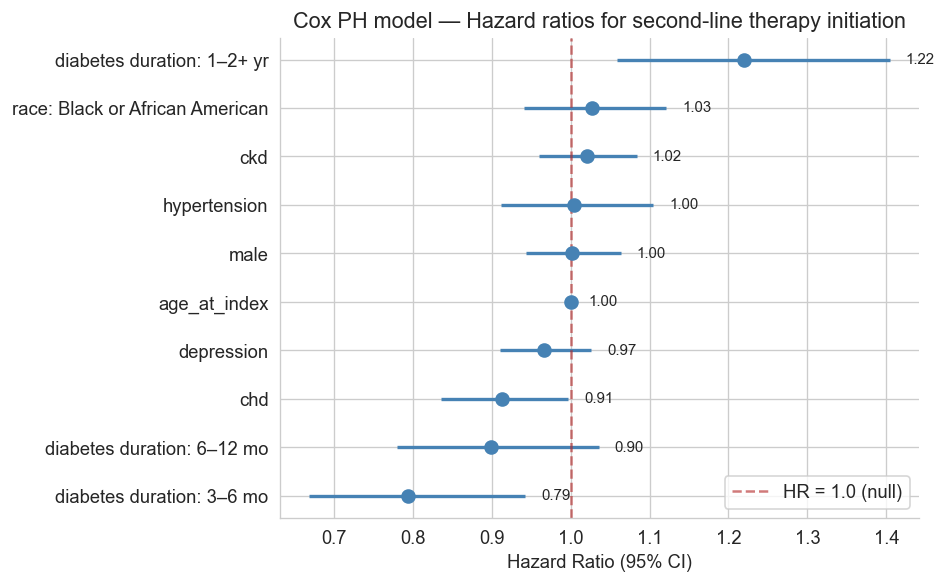

<Figure size 1200x720 with 0 Axes>

In [84]:
# Forest plot of hazard ratios
fig, ax = plt.subplots(figsize=(8, 5))

summary = cph.summary[
    ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%"]
].copy()
summary = summary.sort_values("exp(coef)")

y_pos = range(len(summary))
ax.hlines(
    y_pos,
    summary["exp(coef) lower 95%"],
    summary["exp(coef) upper 95%"],
    color="steelblue",
    linewidth=2,
)
ax.scatter(summary["exp(coef)"], y_pos, color="steelblue", s=60, zorder=3)
ax.axvline(x=1.0, color="firebrick", linestyle="--", alpha=0.6, label="HR = 1.0 (null)")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox PH model — Hazard ratios for second-line therapy initiation")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right")

# Add HR labels
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(
        row["exp(coef) upper 95%"] + 0.02,
        i,
        f"{row['exp(coef)']:.2f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()
plt.savefig("./figures/cox-hazard-ratios.png")

### 2.4 Cox Model Diagnostics

Checking the proportional hazards assumption via Schoenfeld residual tests. A significant p-value (< 0.05) suggests the proportional hazards assumption may be violated for that covariate.

In [85]:
# Proportional hazards test
print("Proportional Hazards Assumption Test (Schoenfeld residuals)")
print("=" * 60)
try:
    ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"PH test result: {e}")
    print("\nNote: With a small sample (N=~50) and no censoring, these tests have")
    print("limited power. Interpret with caution.")

Proportional Hazards Assumption Test (Schoenfeld residuals)
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'diabetes duration: 1–2+ yr' failed the non-proportional test: p-value is 0.0162.

   Advice: with so few unique values (only 2), you can include `strata=['diabetes duration: 1–2+
yr', ...]` in the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



---
## Layer 3: Stratified Cox Models

Running separate Cox models within demographic and clinical subgroups to examine whether the effect of covariates on escalation timing varies across strata. 

For binary stratification variables, we compare HRs across strata; for multi-level variables (age group, race), we describe covariate effects within each stratum.

In [86]:
def run_stratified_cox(df, strat_col, strat_label, covariate_cols):
    """
    Run Cox PH model within each stratum of strat_col.
    Returns a summary DataFrame of HRs across strata.
    """
    results = []

    # Keep diabetes_duration ordered if that's the stratifier
    if strat_col == "diabetes_duration":
        strata = ["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"]
        strata = [s for s in strata if s in df[strat_col].dropna().unique()]
    else:
        strata = sorted(df[strat_col].dropna().unique(), key=lambda x: str(x))

    for stratum in strata:
        subset = df[df[strat_col] == stratum].copy()

        if len(subset) < 10:
            print(f"  Skipping {strat_label}={stratum}: n={len(subset)} (too few)")
            continue

        # Select covariates that exist and vary within this subset
        valid_covs = []
        for c in covariate_cols:
            if c in subset.columns and subset[c].nunique() > 1:
                valid_covs.append(c)

        if len(valid_covs) == 0:
            print(
                f"  Skipping {strat_label}={stratum}: no valid covariates with variance"
            )
            continue

        model_df = subset[["time_to_escalation", "event"] + valid_covs].dropna()

        if len(model_df) < 10:
            print(f"  Skipping {strat_label}={stratum}: n={len(model_df)} after dropna")
            continue

        try:
            cph_s = CoxPHFitter(penalizer=0.1)
            cph_s.fit(model_df, duration_col="time_to_escalation", event_col="event")

            for cov in valid_covs:
                hr = cph_s.hazard_ratios_[cov]
                ci_low = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[0])
                ci_high = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[1])
                p = cph_s.summary.loc[cov, "p"]

                results.append(
                    {
                        "Stratum": f"{strat_label}={stratum}",
                        "N": len(model_df),
                        "Covariate": cov,
                        "HR": hr,
                        "CI_low": ci_low,
                        "CI_high": ci_high,
                        "p": p,
                    }
                )
        except Exception as e:
            print(f"  {strat_label}={stratum}: model failed ({e})")

    return pd.DataFrame(results)


# Prepare diabetes duration dummies first
df["diabetes_duration"] = pd.Categorical(
    df["diabetes_duration"],
    categories=["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"],
    ordered=True,
)

duration_dummies = pd.get_dummies(
    df["diabetes_duration"],
    prefix="diabetes_duration",
    drop_first=False,
)

if "diabetes_duration_0–3 mo" in duration_dummies.columns:
    duration_dummies = duration_dummies.drop(columns=["diabetes_duration_0–3 mo"])
else:
    duration_dummies = duration_dummies.iloc[:, 1:]

df = pd.concat([df, duration_dummies], axis=1)

# Prepare male variable in df if not already
df["male"] = (df["gender"] == "MALE").astype(int)

# Core covariates for stratified models
base_covs = [
    "age_at_index",
    "male",
    "chd",
    "ckd",
    "depression",
    "hypertension",
    "diabetes_duration_3–6 mo",
    "diabetes_duration_6–12 mo",
    "diabetes_duration_1–2+ yr",
]

print("=" * 70)
print("STRATIFIED COX MODELS")
print("=" * 70)

# Example: stratify by diabetes duration
results_diabdur = run_stratified_cox(
    df=df,
    strat_col="diabetes_duration",
    strat_label="Diabetes duration",
    covariate_cols=[
        "age_at_index",
        "male",
        "chd",
        "ckd",
        "depression",
        "hypertension",
    ],  # don't include diabetes_duration dummies here
)

display(results_diabdur)

STRATIFIED COX MODELS


,Stratum,N,Covariate,HR,CI_low,CI_high,p
0,Diabetes duration=0–3 mo,208,age_at_index,0.997790,0.988518,1.007148,0.642223
1,Diabetes duration=0–3 mo,208,male,0.814173,0.617427,1.073612,0.145205
2,Diabetes duration=0–3 mo,208,chd,1.033313,0.761085,1.402911,0.833633
3,Diabetes duration=0–3 mo,208,ckd,0.927573,0.686628,1.253068,0.624189
4,Diabetes duration=0–3 mo,208,depression,1.154651,0.872560,1.527938,0.314353
5,Diabetes duration=0–3 mo,208,hypertension,1.170186,0.610001,2.244806,0.636329
6,Diabetes duration=3–6 mo,333,age_at_index,1.002323,0.994948,1.009751,0.538066
7,Diabetes duration=3–6 mo,333,male,1.096162,0.885120,1.357523,0.400063
8,Diabetes duration=3–6 mo,333,chd,0.858392,0.660029,1.116370,0.254746
9,Diabetes duration=3–6 mo,333,ckd,0.939913,0.757427,1.166364,0.573667


In [87]:
# Stratify by gender
print("\n--- Stratified by Gender ---")
df = df.loc[:, ~df.columns.duplicated()].copy()
gender_results = run_stratified_cox(
    df,
    "gender",
    "Gender",
    [
        "age_at_index",
        "chd",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration_3–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_1–2+ yr",
    ],
)

if len(gender_results) > 0:
    print(gender_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Gender ---
      Stratum    N                 Covariate    HR  CI_low  CI_high     p
Gender=FEMALE 2906              age_at_index 1.001   0.998    1.004 0.433
Gender=FEMALE 2906                       chd 0.951   0.855    1.058 0.358
Gender=FEMALE 2906                       ckd 1.046   0.973    1.124 0.227
Gender=FEMALE 2906                depression 0.935   0.871    1.005 0.067
Gender=FEMALE 2906              hypertension 0.975   0.867    1.096 0.667
Gender=FEMALE 2906  diabetes_duration_3–6 mo 0.746   0.632    0.881 0.001
Gender=FEMALE 2906 diabetes_duration_6–12 mo 0.854   0.755    0.965 0.011
Gender=FEMALE 2906 diabetes_duration_1–2+ yr 1.148   1.016    1.297 0.027
  Gender=MALE 1773              age_at_index 1.000   0.997    1.003 0.920
  Gender=MALE 1773                       chd 0.869   0.758    0.995 0.042
  Gender=MALE 1773                       ckd 0.972   0.886    1.067 0.553
  Gender=MALE 1773                depression 1.032   0.941    1.132 0.501
  Gender

In [88]:
# Stratify by age group
print("\n--- Stratified by Age Group ---")
age_results = run_stratified_cox(
    df,
    "age_group",
    "Age",
    [
        "male",
        "chd",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration_3–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_1–2+ yr",
    ],
)
if len(age_results) > 0:
    print(age_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Age Group ---
  Stratum    N                 Covariate    HR  CI_low  CI_high     p
Age=18-44  202                      male 1.044   0.791    1.378 0.759
Age=18-44  202                       chd 0.915   0.620    1.349 0.653
Age=18-44  202                       ckd 0.810   0.602    1.091 0.166
Age=18-44  202                depression 0.676   0.503    0.909 0.010
Age=18-44  202              hypertension 0.947   0.608    1.475 0.809
Age=18-44  202  diabetes_duration_3–6 mo 0.808   0.442    1.477 0.488
Age=18-44  202 diabetes_duration_6–12 mo 0.948   0.597    1.506 0.821
Age=18-44  202 diabetes_duration_1–2+ yr 1.164   0.734    1.846 0.520
Age=45-64  738                      male 0.992   0.863    1.141 0.915
Age=45-64  738                       chd 0.935   0.764    1.145 0.516
Age=45-64  738                       ckd 1.041   0.901    1.203 0.582
Age=45-64  738                depression 0.982   0.849    1.135 0.804
Age=45-64  738              hypertension 1.012   0.801   

In [89]:
# Stratify by CHD
print("\n--- Stratified by CHD ---")
chd_results = run_stratified_cox(
    df,
    "chd",
    "CHD",
    [
        "age_at_index",
        "male",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration_3–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_1–2+ yr",
    ],
)
if len(chd_results) > 0:
    print(chd_results.to_string(index=False, float_format="%.3f"))


--- Stratified by CHD ---
Stratum    N                 Covariate    HR  CI_low  CI_high     p
  CHD=0  621              age_at_index 0.998   0.993    1.004 0.579
  CHD=0  621                      male 1.062   0.908    1.243 0.450
  CHD=0  621                       ckd 1.005   0.850    1.188 0.957
  CHD=0  621                depression 1.000   0.844    1.186 0.998
  CHD=0  621              hypertension 0.893   0.635    1.254 0.513
  CHD=0  621  diabetes_duration_3–6 mo 0.975   0.727    1.309 0.868
  CHD=0  621 diabetes_duration_6–12 mo 0.941   0.750    1.181 0.600
  CHD=0  621 diabetes_duration_1–2+ yr 1.360   1.082    1.711 0.009
  CHD=1 4058              age_at_index 1.001   0.999    1.003 0.343
  CHD=1 4058                      male 0.993   0.935    1.056 0.829
  CHD=1 4058                       ckd 1.019   0.959    1.083 0.547
  CHD=1 4058                depression 0.967   0.911    1.027 0.280
  CHD=1 4058              hypertension 1.014   0.922    1.116 0.769
  CHD=1 4058  diabete

In [90]:
# Stratify by CKD
print("\n--- Stratified by CKD ---")
ckd_results = run_stratified_cox(
    df,
    "ckd",
    "CKD",
    [
        "age_at_index",
        "male",
        "chd",
        "depression",
        "hypertension",
        "diabetes_duration_3–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_1–2+ yr",
    ],
)
if len(ckd_results) > 0:
    print(ckd_results.to_string(index=False, float_format="%.3f"))


--- Stratified by CKD ---
Stratum    N                 Covariate    HR  CI_low  CI_high     p
  CKD=0 1996              age_at_index 0.999   0.996    1.003 0.691
  CKD=0 1996                      male 1.035   0.948    1.129 0.444
  CKD=0 1996                       chd 0.927   0.835    1.030 0.159
  CKD=0 1996                depression 0.971   0.891    1.059 0.512
  CKD=0 1996              hypertension 0.962   0.822    1.125 0.625
  CKD=0 1996  diabetes_duration_3–6 mo 0.856   0.716    1.024 0.089
  CKD=0 1996 diabetes_duration_6–12 mo 0.892   0.778    1.023 0.102
  CKD=0 1996 diabetes_duration_1–2+ yr 1.217   1.062    1.395 0.005
  CKD=1 2683              age_at_index 1.001   0.999    1.004 0.287
  CKD=1 2683                      male 0.979   0.909    1.056 0.586
  CKD=1 2683                       chd 0.911   0.791    1.049 0.196
  CKD=1 2683                depression 0.971   0.901    1.047 0.440
  CKD=1 2683              hypertension 1.022   0.913    1.144 0.701
  CKD=1 2683  diabete

In [91]:
# Stratify by Depression
print("\n--- Stratified by Depression ---")
dep_results = run_stratified_cox(
    df,
    "depression",
    "Depression",
    [
        "age_at_index",
        "male",
        "chd",
        "ckd",
        "hypertension",
        "diabetes_duration_3–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_1–2+ yr",
    ],
)
if len(dep_results) > 0:
    print(dep_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Depression ---
     Stratum    N                 Covariate    HR  CI_low  CI_high     p
Depression=0 2152              age_at_index 0.999   0.996    1.002 0.515
Depression=0 2152                      male 0.955   0.878    1.038 0.279
Depression=0 2152                       chd 0.940   0.848    1.042 0.241
Depression=0 2152                       ckd 1.018   0.937    1.106 0.680
Depression=0 2152              hypertension 0.952   0.815    1.111 0.531
Depression=0 2152  diabetes_duration_3–6 mo 0.915   0.760    1.101 0.345
Depression=0 2152 diabetes_duration_6–12 mo 0.945   0.825    1.082 0.416
Depression=0 2152 diabetes_duration_1–2+ yr 1.213   1.059    1.389 0.005
Depression=1 2527              age_at_index 1.002   0.999    1.004 0.212
Depression=1 2527                      male 1.040   0.963    1.123 0.319
Depression=1 2527                       chd 0.895   0.773    1.036 0.138
Depression=1 2527                       ckd 1.015   0.938    1.100 0.705
Depression=1 2527

In [92]:
# Stratify by Hypertension
print("\n--- Stratified by Hypertension ---")
htn_results = run_stratified_cox(
    df,
    "hypertension",
    "Hypertension",
    [
        "age_at_index",
        "male",
        "chd",
        "ckd",
        "depression",
        "diabetes_duration_3–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_1–2+ yr",
    ],
)
if len(htn_results) > 0:
    print(htn_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Hypertension ---
       Stratum    N                 Covariate    HR  CI_low  CI_high     p
Hypertension=0 4212              age_at_index 1.001   0.999    1.003 0.490
Hypertension=0 4212                      male 0.994   0.936    1.055 0.848
Hypertension=0 4212                       chd 0.919   0.843    1.001 0.054
Hypertension=0 4212                       ckd 1.015   0.956    1.078 0.620
Hypertension=0 4212                depression 0.964   0.908    1.023 0.222
Hypertension=0 4212  diabetes_duration_3–6 mo 0.818   0.714    0.939 0.004
Hypertension=0 4212 diabetes_duration_6–12 mo 0.911   0.823    1.007 0.068
Hypertension=0 4212 diabetes_duration_1–2+ yr 1.200   1.085    1.326 0.000
Hypertension=1  467              age_at_index 1.000   0.994    1.007 0.981
Hypertension=1  467                      male 1.073   0.894    1.288 0.449
Hypertension=1  467                       chd 1.000   0.706    1.416 1.000
Hypertension=1  467                       ckd 1.058   0.877    1

### 3.1 Median Time to Escalation — Summary Table by Subgroup

A consolidated view of median escalation times and interquartile ranges across all stratification variables.

In [93]:
def median_by_subgroup(df, col, label):
    """Compute median (IQR) time to escalation by subgroup."""
    rows = []

    if col == "diabetes_duration":
        order = ["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"]
        values = [v for v in order if v in df[col].dropna().unique()]
    else:
        values = sorted(df[col].dropna().unique(), key=lambda x: str(x))

    for val in values:
        subset = df[df[col] == val]["time_to_escalation"].dropna()
        rows.append({
            "Variable": label,
            "Subgroup": str(val),
            "N": len(subset),
            "Median (days)": subset.median(),
            "IQR": f"{subset.quantile(0.25):.0f}–{subset.quantile(0.75):.0f}",
            "Mean (days)": subset.mean(),
        })

    return pd.DataFrame(rows)


strat_summary = pd.concat([
    median_by_subgroup(df, "gender", "Gender"),
    median_by_subgroup(df, "age_group", "Age group"),
    median_by_subgroup(df, "race", "Race"),
    median_by_subgroup(df, "chd", "CHD"),
    median_by_subgroup(df, "ckd", "CKD"),
    median_by_subgroup(df, "depression", "Depression"),
    median_by_subgroup(df, "hypertension", "Hypertension"),
    median_by_subgroup(df, "diabetes_duration", "Diabetes duration"),
], ignore_index=True)

print("Median time to escalation by subgroup:")
print("=" * 75)
print(strat_summary.to_string(index=False, float_format="%.1f"))

Median time to escalation by subgroup:
         Variable                  Subgroup    N  Median (days)    IQR  Mean (days)
           Gender                    FEMALE 2906           68.0 30–128         86.1
           Gender                      MALE 1773           66.0 31–125         85.5
        Age group                     18-44  202           70.0 27–122         84.2
        Age group                     45-64  738           69.0 28–133         86.9
        Age group                     65-74 1545           70.0 32–127         87.3
        Age group                       75+ 2194           66.0 31–125         84.7
             Race Black or African American  591           67.0 29–126         85.2
             Race                     White 4088           67.0 30–127         86.0
              CHD                         0  621           61.0 28–121         82.2
              CHD                         1 4058           69.0 31–127         86.4
              CKD                    

---
## Layer 4: Treatment Pathway Analysis

Using the full drug-exposure-level dataset (all rows, not collapsed), we examine the sequences of second-line therapy following metformin initiation.

This addresses a key feedback point: moving beyond simply identifying the *first* second-line agent to describing the *trajectories* of treatment — common sequences, switching patterns, and the number of distinct agents used per patient.

### 4.1 Drug Exposure Counts and Sequencing

For each patient, we reconstruct the ordered sequence of second-line drugs received after metformin initiation.

Exposures per patient:
count    9116.0
mean        1.8
std         1.2
min         1.0
25%         1.0
50%         1.0
75%         2.0
max         9.0
Name: n_exposures, dtype: float64

Distinct second-line drugs per patient:
n_distinct_drugs
1    5540
2    2571
3     786
4     188
5      28
6       2
7       1
Name: count, dtype: int64


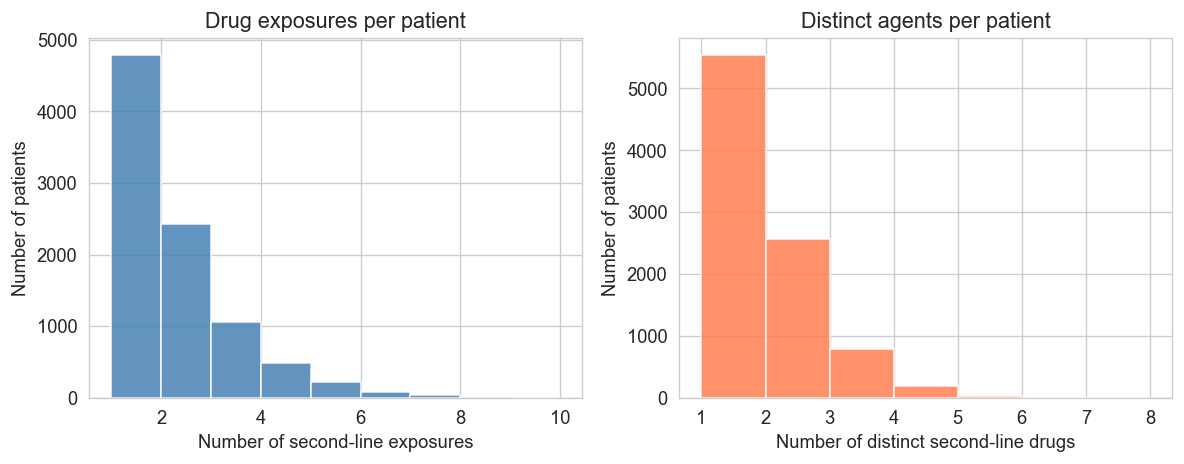

<Figure size 1200x720 with 0 Axes>

In [94]:
# Sort all exposures by patient and date
pathways = df_raw.sort_values(["person_id", "second_line_start_date"]).copy()

# Build ordered drug sequence per patient
patient_sequences = (
    pathways.groupby("person_id")["second_line_drug_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"second_line_drug_name": "drug_sequence"})
)

# Number of exposures per patient
patient_sequences["n_exposures"] = patient_sequences["drug_sequence"].apply(len)

# Number of distinct drugs per patient
patient_sequences["n_distinct_drugs"] = patient_sequences["drug_sequence"].apply(
    lambda x: len(set(x))
)

print("Exposures per patient:")
print(patient_sequences["n_exposures"].describe().round(1))
print()
print("Distinct second-line drugs per patient:")
print(patient_sequences["n_distinct_drugs"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
patient_sequences["n_exposures"].hist(
    ax=axes[0],
    bins=range(1, patient_sequences["n_exposures"].max() + 2),
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)
axes[0].set_xlabel("Number of second-line exposures")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Drug exposures per patient")

patient_sequences["n_distinct_drugs"].hist(
    ax=axes[1],
    bins=range(1, patient_sequences["n_distinct_drugs"].max() + 2),
    color="coral",
    edgecolor="white",
    alpha=0.85,
)
axes[1].set_xlabel("Number of distinct second-line drugs")
axes[1].set_ylabel("Number of patients")
axes[1].set_title("Distinct agents per patient")

plt.tight_layout()
plt.show()
plt.savefig("./figures/drugs-per-patient.png")

### 4.2 Most Common Treatment Pathways

The top treatment pathways (ordered sequences of second-line drugs) observed in the cohort. Each pathway is read left to right as the temporal order of drugs received.

In [95]:
# Convert sequences to readable pathway strings. Dedupe first.
patient_sequences["drug_sequence"] = patient_sequences["drug_sequence"].apply(
    lambda seq: [seq[0]] + [seq[i] for i in range(1, len(seq)) if seq[i] != seq[i - 1]]
)
patient_sequences["pathway"] = patient_sequences["drug_sequence"].apply(
    lambda x: " → ".join(x)
)

# Top pathways
pathway_counts = patient_sequences["pathway"].value_counts().head(15)

print("Top 15 treatment pathways after metformin:")
print("=" * 65)
for i, (pathway, n) in enumerate(pathway_counts.items(), 1):
    pct = n / len(patient_sequences) * 100
    print(f"  {i:>2d}. [{n:>2d} pts, {pct:>4.1f}%]  metformin → {pathway}")

Top 15 treatment pathways after metformin:
   1. [2522 pts, 27.7%]  metformin → glyburide
   2. [1524 pts, 16.7%]  metformin → glipizide
   3. [490 pts,  5.4%]  metformin → rosiglitazone
   4. [396 pts,  4.3%]  metformin → glyburide → glipizide
   5. [378 pts,  4.1%]  metformin → glimepiride
   6. [364 pts,  4.0%]  metformin → glipizide → glyburide
   7. [364 pts,  4.0%]  metformin → pioglitazone
   8. [154 pts,  1.7%]  metformin → rosiglitazone → glyburide
   9. [142 pts,  1.6%]  metformin → sitagliptin
  10. [119 pts,  1.3%]  metformin → glyburide → rosiglitazone
  11. [110 pts,  1.2%]  metformin → glyburide → glimepiride
  12. [109 pts,  1.2%]  metformin → rosiglitazone → glipizide
  13. [83 pts,  0.9%]  metformin → pioglitazone → glyburide
  14. [83 pts,  0.9%]  metformin → glyburide → pioglitazone
  15. [82 pts,  0.9%]  metformin → glyburide → glipizide → glyburide


### 4.3 State Transition Analysis

Which drugs do patients transition *between*? This matrix shows the count of observed transitions from one second-line drug to the next in the treatment sequence.

State transition matrix (from → to):
to_drug           glimepiride  glipizide  glyburide  insulin detemir  \
from_drug                                                              
glimepiride                 0        205        200                0   
glipizide                 229          0        848                1   
glyburide                 282        876          0                2   
insulin detemir             0          1          1                0   
insulin glargine            2         10          7                0   
nateglinide                 5         19         31                0   
pioglitazone               57        156        219                0   
repaglinide                 9         28         45                0   
rosiglitazone              83        256        357                2   
saxagliptin                 1          1          0                0   
sitagliptin                25         53         83                0   
All                       6

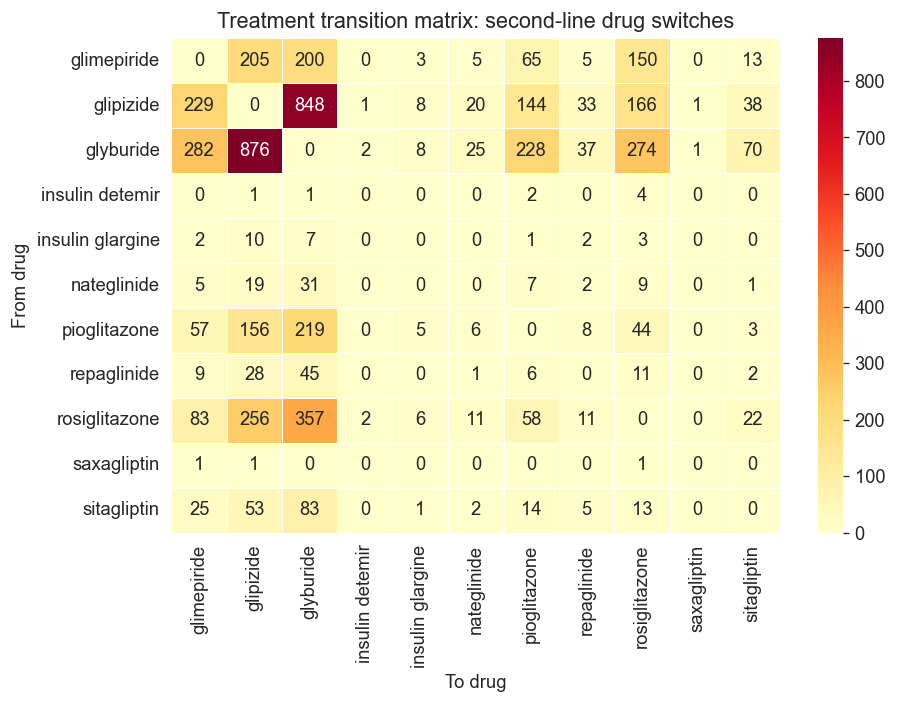


Top 10 most common transitions:
  glyburide → glipizide: 876
  glipizide → glyburide: 848
  rosiglitazone → glyburide: 357
  glyburide → glimepiride: 282
  glyburide → rosiglitazone: 274
  rosiglitazone → glipizide: 256
  glipizide → glimepiride: 229
  glyburide → pioglitazone: 228
  pioglitazone → glyburide: 219
  glimepiride → glipizide: 205


<Figure size 1200x720 with 0 Axes>

In [96]:
# Build transition pairs
transitions = []
for _, row in patient_sequences.iterrows():
    seq = row['drug_sequence']
    for i in range(len(seq) - 1):
        transitions.append((seq[i], seq[i+1]))

if len(transitions) > 0:
    trans_df = pd.DataFrame(transitions, columns=['from_drug', 'to_drug'])
    
    # Transition matrix
    trans_matrix = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'], margins=True)
    print("State transition matrix (from → to):")
    print(trans_matrix)
    print()
    
    # Heatmap (without margins)
    trans_clean = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(trans_clean, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('To drug')
    ax.set_ylabel('From drug')
    ax.set_title('Treatment transition matrix: second-line drug switches')
    plt.tight_layout()
    plt.show()
    plt.savefig("./figures/drugs-transition-matrix.png")
    
    # Most common transitions
    print("\nTop 10 most common transitions:")
    top_trans = trans_df.value_counts().head(10)
    for (fr, to), n in top_trans.items():
        print(f"  {fr} → {to}: {n}")
else:
    print("No transitions observed (all patients had only one second-line drug).")

### 4.4 Drug Class Grouping

Grouping individual drugs into pharmacologic classes to reveal higher-level treatment patterns.

First second-line agent by drug class:
----------------------------------------
  Sulfonylurea               n=3723  (79.6%)
  Thiazolidinedione          n=728  (15.6%)
  Meglitinide                n=129  (2.8%)
  DPP-4 inhibitor            n= 78  (1.7%)
  Other                      n= 21  (0.4%)


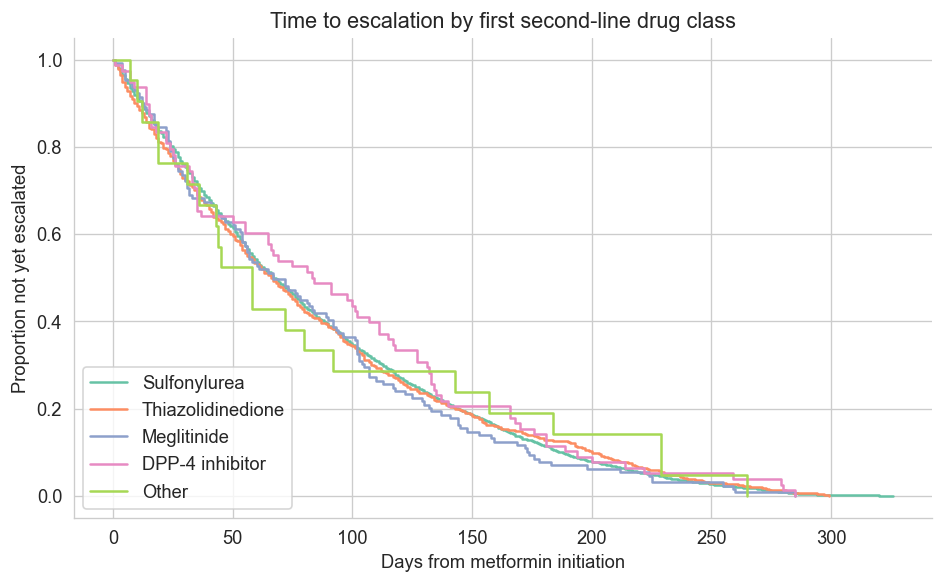

<Figure size 1200x720 with 0 Axes>

In [97]:
# Drug class mapping
drug_class_map = {
    'glyburide': 'Sulfonylurea',
    'glipizide': 'Sulfonylurea',
    'glimepiride': 'Sulfonylurea',
    'pioglitazone': 'Thiazolidinedione',
    'rosiglitazone': 'Thiazolidinedione',
    'sitagliptin': 'DPP-4 inhibitor',
    'nateglinide': 'Meglitinide',
    'repaglinide': 'Meglitinide',
}

# Map first drug to class
df['first_drug_class'] = df['second_line_drug_name'].map(drug_class_map).fillna('Other')

# Class distribution
class_counts = df['first_drug_class'].value_counts()
print("First second-line agent by drug class:")
print("-" * 40)
for cls, n in class_counts.items():
    print(f"  {cls:<25s}  n={n:>3d}  ({n/len(df)*100:.1f}%)")

# KM by drug class
fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()
palette = sns.color_palette("Set2", len(class_counts))

for i, cls in enumerate(class_counts.index):
    mask = df['first_drug_class'] == cls
    if mask.sum() >= 2:
        kmf.fit(df.loc[mask, 'time_to_escalation'],
                event_observed=df.loc[mask, 'event'],
                label=cls)
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])

ax.set_xlabel('Days from metformin initiation')
ax.set_ylabel('Proportion not yet escalated')
ax.set_title('Time to escalation by first second-line drug class')
ax.legend(loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
plt.savefig("./figures/time-to-escalation-drug-class.png")

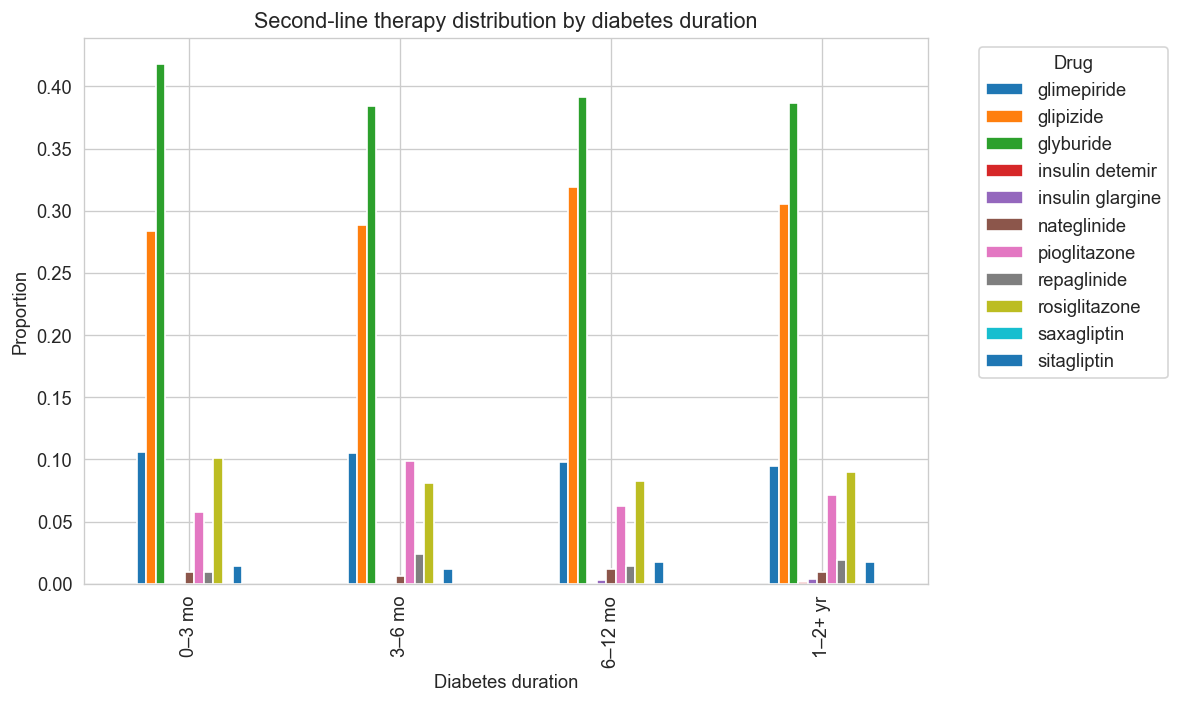

<Figure size 1200x720 with 0 Axes>

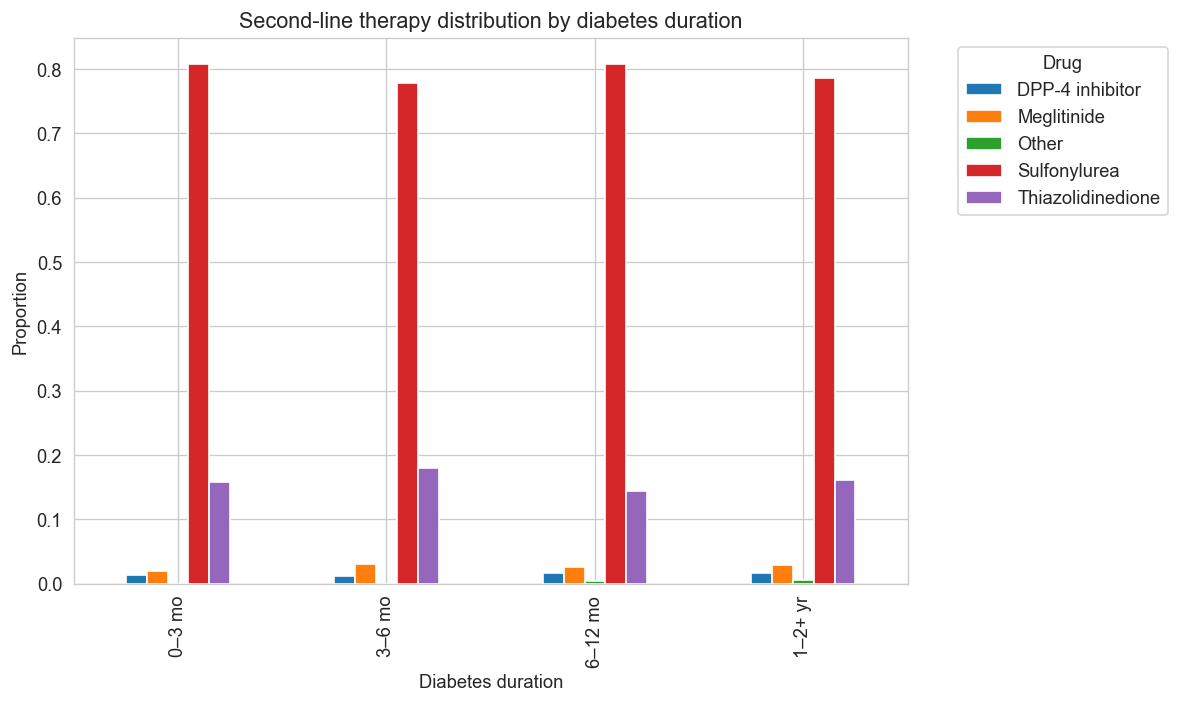

<Figure size 1200x720 with 0 Axes>

In [98]:
ct = pd.crosstab(
    df["diabetes_duration"], df["second_line_drug_name"], normalize="index"
)

ct.plot(kind="bar", figsize=(10, 6))

plt.title("Second-line therapy distribution by diabetes duration")
plt.ylabel("Proportion")
plt.xlabel("Diabetes duration")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
plt.savefig("./figures/2nd-line-distribution-small.png")

ct = pd.crosstab(df["diabetes_duration"], df["first_drug_class"], normalize="index")

ct.plot(kind="bar", figsize=(10, 6))

plt.title("Second-line therapy distribution by diabetes duration")
plt.ylabel("Proportion")
plt.xlabel("Diabetes duration")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
plt.savefig("./figures/2nd-line-distribution-big.png")

---
## Study Limitations and Methodological Notes

1. **Selection bias:** This dataset includes only patients who were escalated to a second-line agent. Patients who remained on metformin monotherapy throughout the observation period are excluded. All survival analyses therefore describe the *distribution of escalation timing among those who escalated*, not the overall probability of escalation.

2. **No censoring:** Because all patients in the dataset experienced the event, there are no censored observations. The KM estimator reduces to the empirical CDF, and the Cox model estimates relative differences in escalation speed without the usual censoring adjustments.

3. **Small sample size:** With ~50 unique patients, statistical power is limited. Confidence intervals on hazard ratios are wide, stratified analyses have very small cell sizes, and proportional hazards tests have low power. Results should be interpreted as exploratory.

4. **Unmeasured confounders:** Key clinical variables — HbA1c, BMI, renal function (eGFR), diabetes duration — are not available in this dataset. Prescriber behavior and clinical inertia are also unmeasured. As discussed in the DAG, disease severity is the most important unmeasured confounder.

5. **Observation intensity bias:** Patients with more healthcare encounters have more opportunities for escalation to be documented. Healthcare utilization is not available as a covariate in this extract.

6. **Temporal context:** The cohort start dates cluster around January 2009, which precedes the widespread adoption of SGLT2 inhibitors and GLP-1 receptor agonists. The treatment landscape reflected here is historically specific.

7. **Outcome definition:** The distinction between add-on therapy and drug switching is not explicitly modeled. Both are captured as "second-line initiation."